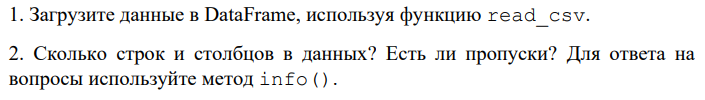

In [174]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv('house_price.csv')

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

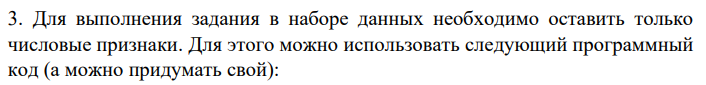

In [175]:
numeric_dtypes = ['int64', 'float64']
numerics = []
for i in df.columns:
    if df[i].dtype in numeric_dtypes:
        numerics.append(i)
df = df[numerics]

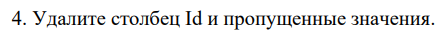

In [176]:
del df['Id']
df = df.fillna(df.median())
for col in df.columns:
    if df[col].isna().sum() > 0:
        median_val = df[col].median()
        if pd.notna(median_val):
            df[col] = df[col].fillna(median_val)
            print(f"{col}: медиана = {median_val:.2f}")

cols_to_drop = []
for col in df.columns:
    nan_pct = 100 * df[col].isna().sum() / len(df)
    if nan_pct > 90:
        cols_to_drop.append(col)
        print(f"{col}: {nan_pct:.1f}% NaN удаляем")

if cols_to_drop:
    df = df.drop(columns=cols_to_drop)

nan_final = df.isna().sum().sum()
print(f"     NaN осталось: {nan_final}")

if nan_final > 0:
    print(f"Удаляем оставшиеся строки с NaN")
    df = df.dropna()
    print(f"Осталось строк: {len(df)}")

print(df)


Unnamed: 81: 100.0% NaN удаляем
     NaN осталось: 0
      MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
0             60         65.0     8450            7            5       2003   
1             20         80.0     9600            6            8       1976   
2             60         68.0    11250            7            5       2001   
3             70         60.0     9550            7            5       1915   
4             60         84.0    14260            8            5       2000   
...          ...          ...      ...          ...          ...        ...   
1455          60         62.0     7917            6            5       1999   
1456          20         85.0    13175            6            6       1978   
1457          70         66.0     9042            7            9       1941   
1458          20         68.0     9717            5            6       1950   
1459          20         75.0     9937            5            6       1965   

c:\Users\anton\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


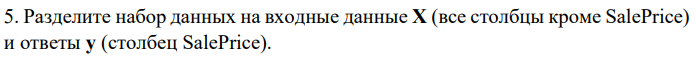

In [177]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [178]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

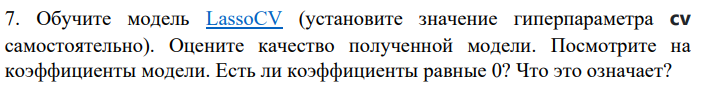

In [179]:
from sklearn.linear_model import LassoCV
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_train, y_train)

train_score = lasso.score(X_train, y_train)
test_score = lasso.score(X_test, y_test)

print(f"Лучший параметр alpha: {lasso.alpha_:.6f}")
print(f"R² на обучающей выборке: {train_score:.4f}")
print(f"R² на тестовой выборке: {test_score:.4f}")

# Анализ коэффициентов
print(f"\nАнализ коэффициентов:")
print(f"Всего коэффициентов: {len(lasso.coef_)}")
zero_coef = np.sum(lasso.coef_ == 0)
print(f"Коэффициентов равных 0: {zero_coef}")
print(f"Процент обнуленных признаков: {zero_coef/len(lasso.coef_)*100:.1f}%")

# Ненулевые коэффициенты
print(f"\nНенулевые коэффициенты:")
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_
})
feature_importance = feature_importance[feature_importance['Coefficient'] != 0].sort_values(
    'Coefficient', key=abs, ascending=False
)
print(feature_importance.to_string(index=False))

Лучший параметр alpha: 230961.324931
R² на обучающей выборке: 0.6925
R² на тестовой выборке: 0.7701

Анализ коэффициентов:
Всего коэффициентов: 36
Коэффициентов равных 0: 26
Процент обнуленных признаков: 72.2%

Ненулевые коэффициенты:
     Feature  Coefficient
   YearBuilt   353.544898
  GarageArea    72.582952
   GrLivArea    63.046860
YearRemodAdd    60.943535
  WoodDeckSF    29.289802
  MasVnrArea    29.138554
 TotalBsmtSF    26.190015
  BsmtFinSF1    10.190985
     MiscVal    -3.825704
     LotArea     0.314283


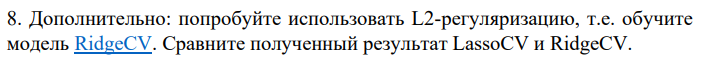

In [180]:
from sklearn.linear_model import RidgeCV
ridge = RidgeCV(cv=5, alphas=np.logspace(-3, 4, 8))
ridge.fit(X_train, y_train)

ridge_train_score = ridge.score(X_train, y_train)
ridge_test_score = ridge.score(X_test, y_test)

print(f"\n--- RidgeCV ---")
print(f"Лучший параметр alpha: {ridge.alpha_:.6f}")
print(f"R² на обучающей выборке: {ridge_train_score:.4f}")
print(f"R² на тестовой выборке: {ridge_test_score:.4f}")


--- RidgeCV ---
Лучший параметр alpha: 100.000000
R² на обучающей выборке: 0.7988
R² на тестовой выборке: 0.8254


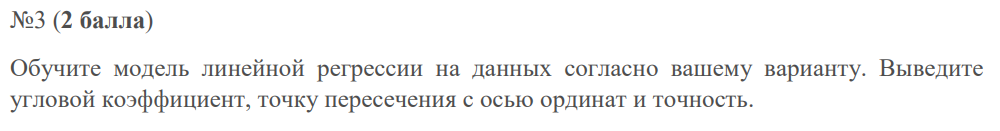

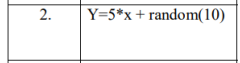

In [181]:
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Генерируем данные согласно варианту: Y = 5*x + random(10)
np.random.seed(42)
n_samples = 100
x = np.linspace(0, 10, n_samples).reshape(-1, 1)
y = 5 * x.ravel() + np.random.uniform(0, 10, n_samples)

# Обучаем модель линейной регрессии
model = LinearRegression()
model.fit(x, y)

# Получаем параметры модели
slope = model.coef_[0]
intercept = model.intercept_ 
y_pred = model.predict(x)

# Вычисляем метрики качества
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)

print(f"r2: {r2}")
print(f"mse: {mse}")
print(f"rmse: {rmse}")
print(f"mae: {mae}")

r2: 0.9607348542245074
mse: 8.757924860889648
rmse: 2.9593791343607276
mae: 2.600187318920805


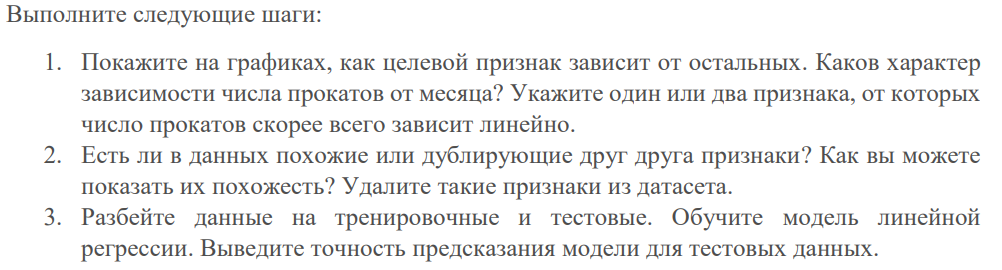

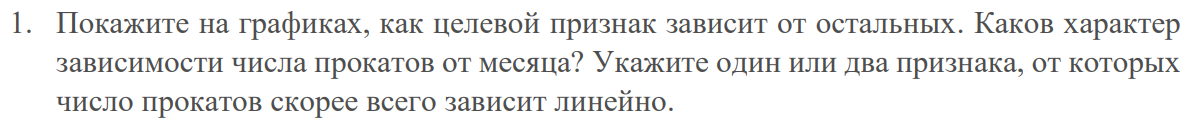


Преобразуем столбцы в числовой формат...

NaN найдено: 731
Распределение NaN:
       • Unnamed: 13: 731

Удаляем полностью пустые столбцы...
Unnamed: 13: 100.0% NaN удаляем

Заполняем NaN медианой...

Финальная проверка...
     NaN осталось: 0

Проверяем бесконечности...
\Данные очищены и готовы!
Финальный размер: 731 строк13 столбцов
Диапазон cnt: 22 - 8714
   • Минимум: месяц 1 (~2176 прокатов)
   • Максимум: месяц 6 (~5772 прокатов)
   • Тип: гаусовая-подобная (пик в летние месяцы)
   • Вывод: сезонная зависимость


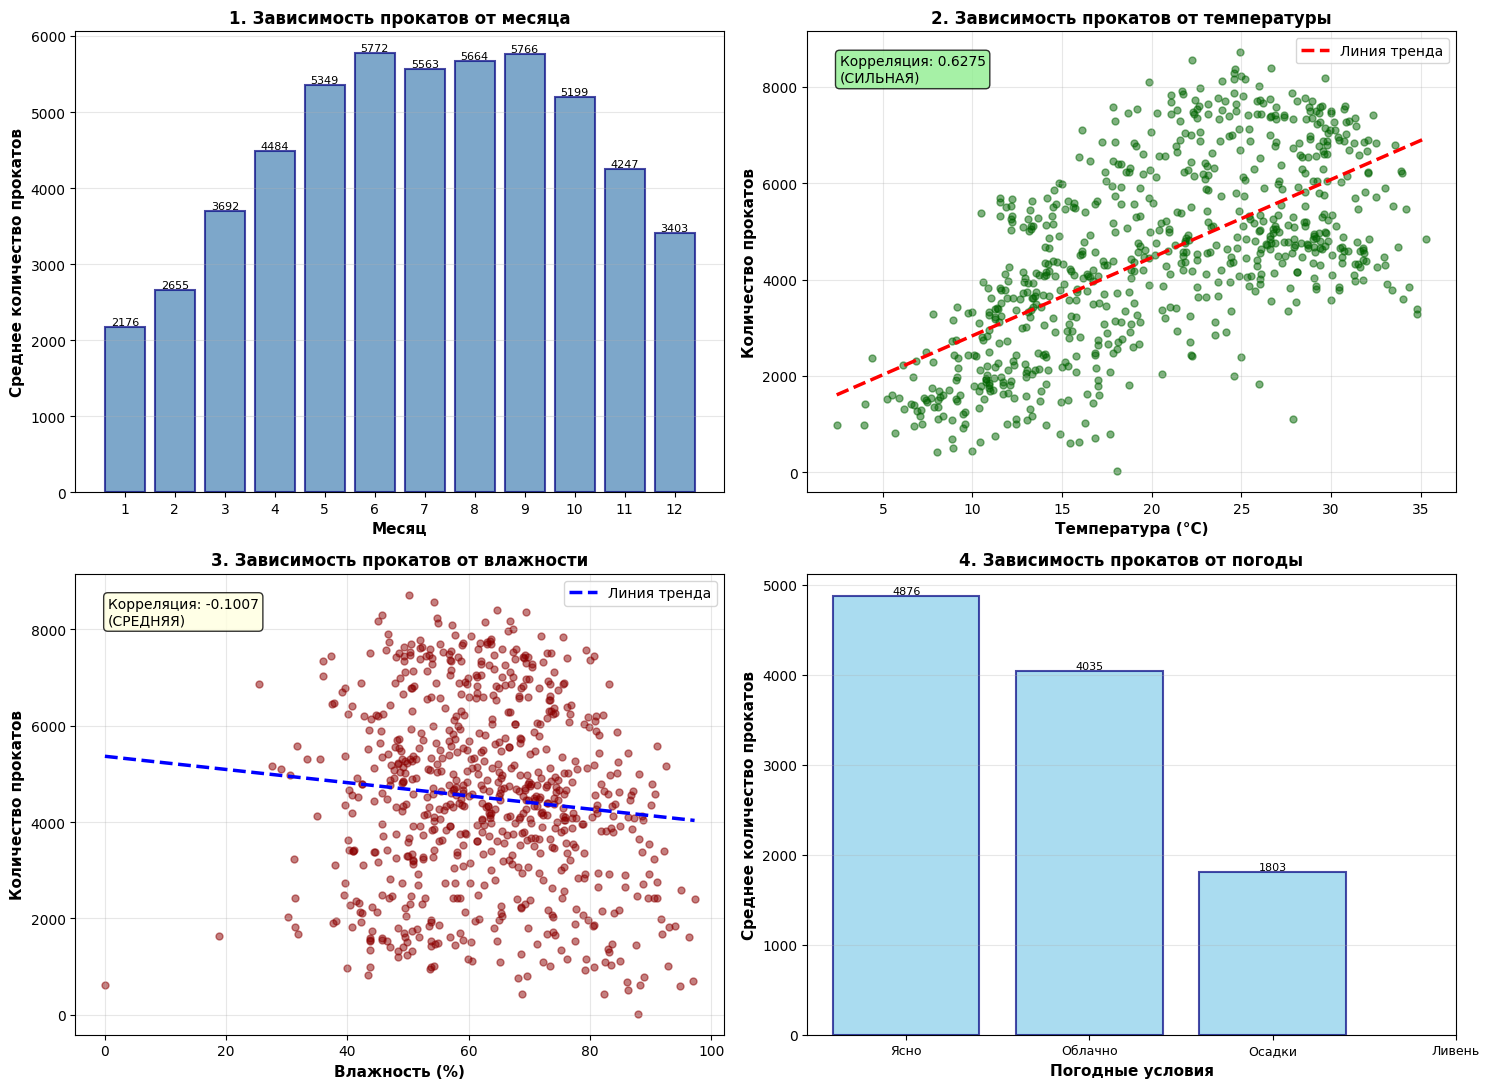

In [182]:
df = pd.read_csv('bikes_rent.csv', decimal=',')

print(f"\nПреобразуем столбцы в числовой формат...")
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

nan_before = df.isna().sum().sum()
print(f"\nNaN найдено: {nan_before}")

if nan_before > 0:
    print(f"Распределение NaN:")
    for col in df.columns:
        nan_cnt = df[col].isna().sum()
        if nan_cnt > 0:
            print(f"       • {col}: {nan_cnt}")

print(f"\nУдаляем полностью пустые столбцы...")
cols_to_drop = []
for col in df.columns:
    nan_pct = 100 * df[col].isna().sum() / len(df)
    if nan_pct > 90:
        cols_to_drop.append(col)
        print(f"{col}: {nan_pct:.1f}% NaN удаляем")

if cols_to_drop:
    df = df.drop(columns=cols_to_drop)

print(f"\nЗаполняем NaN медианой...")
for col in df.columns:
    if df[col].isna().sum() > 0:
        median_val = df[col].median()
        if pd.notna(median_val):
            df[col] = df[col].fillna(median_val)
            print(f"{col}: медиана = {median_val:.2f}")

print(f"\nФинальная проверка...")
nan_final = df.isna().sum().sum()
print(f"     NaN осталось: {nan_final}")

if nan_final > 0:
    print(f"Удаляем оставшиеся строки с NaN...")
    df = df.dropna()
    print(f"Осталось строк: {len(df)}")

print(f"\nПроверяем бесконечности...")
inf_count = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
if inf_count > 0:
    print(f"Найдено бесконечностей: {inf_count}")
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()
    print(f"Осталось строк: {len(df)}")

print(f"\Данные очищены и готовы!")
print(f"Финальный размер: {df.shape[0]} строк{df.shape[1]} столбцов")
print(f"Диапазон cnt: {df['cnt'].min():.0f} - {df['cnt'].max():.0f}")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'cnt' in numeric_cols:
    numeric_cols.remove('cnt')

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1.1 Зависимость от месяца
ax = axes[0, 0]
monthly = df.groupby('mnth')['cnt'].mean()
bars = ax.bar(monthly.index, monthly.values, color='steelblue', alpha=0.7, edgecolor='navy', linewidth=1.5)
ax.set_xlabel('Месяц', fontweight='bold', fontsize=11)
ax.set_ylabel('Среднее количество прокатов', fontweight='bold', fontsize=11)
ax.set_title('1. Зависимость прокатов от месяца', fontweight='bold', fontsize=12)
ax.set_xticks(range(1, 13))
ax.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=8)

min_month = monthly.idxmin()
max_month = monthly.idxmax()
print(f"   • Минимум: месяц {min_month} (~{monthly.min():.0f} прокатов)")
print(f"   • Максимум: месяц {max_month} (~{monthly.max():.0f} прокатов)")
print(f"   • Тип: гаусовая-подобная (пик в летние месяцы)")
print(f"   • Вывод: сезонная зависимость")

ax = axes[0, 1]
ax.scatter(df['temp'], df['cnt'], alpha=0.5, s=25, color='darkgreen', edgecolor='darkgreen')
z = np.polyfit(df['temp'], df['cnt'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['temp'].min(), df['temp'].max(), 100)
ax.plot(x_line, p(x_line), "r--", linewidth=2.5, label='Линия тренда')
ax.set_xlabel('Температура (°C)', fontweight='bold', fontsize=11)
ax.set_ylabel('Количество прокатов', fontweight='bold', fontsize=11)
ax.set_title('2. Зависимость прокатов от температуры', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3)
corr_temp = df['temp'].corr(df['cnt'])
ax.text(0.05, 0.95, f'Корреляция: {corr_temp:.4f}\n(СИЛЬНАЯ)', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
ax.legend(fontsize=10)

# 1.3 Зависимость от влажности
ax = axes[1, 0]
ax.scatter(df['hum'], df['cnt'], alpha=0.5, s=25, color='darkred', edgecolor='darkred')
z = np.polyfit(df['hum'], df['cnt'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['hum'].min(), df['hum'].max(), 100)
ax.plot(x_line, p(x_line), "b--", linewidth=2.5, label='Линия тренда')
ax.set_xlabel('Влажность (%)', fontweight='bold', fontsize=11)
ax.set_ylabel('Количество прокатов', fontweight='bold', fontsize=11)
ax.set_title('3. Зависимость прокатов от влажности', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3)
corr_hum = df['hum'].corr(df['cnt'])
ax.text(0.05, 0.95, f'Корреляция: {corr_hum:.4f}\n(СРЕДНЯЯ)', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.legend(fontsize=10)

# 1.4 Зависимость от погодных условий
ax = axes[1, 1]
weather = df.groupby('weathersit')['cnt'].mean()
bars = ax.bar(weather.index, weather.values, color='skyblue', alpha=0.7, edgecolor='navy', linewidth=1.5)
ax.set_xlabel('Погодные условия', fontweight='bold', fontsize=11)
ax.set_ylabel('Среднее количество прокатов', fontweight='bold', fontsize=11)
ax.set_title('4. Зависимость прокатов от погоды', fontweight='bold', fontsize=12)
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['Ясно', 'Облачно', 'Осадки', 'Ливень'], fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

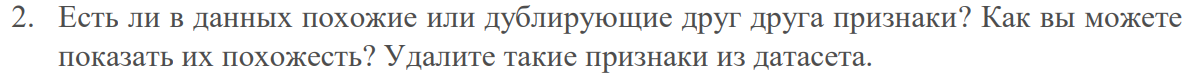

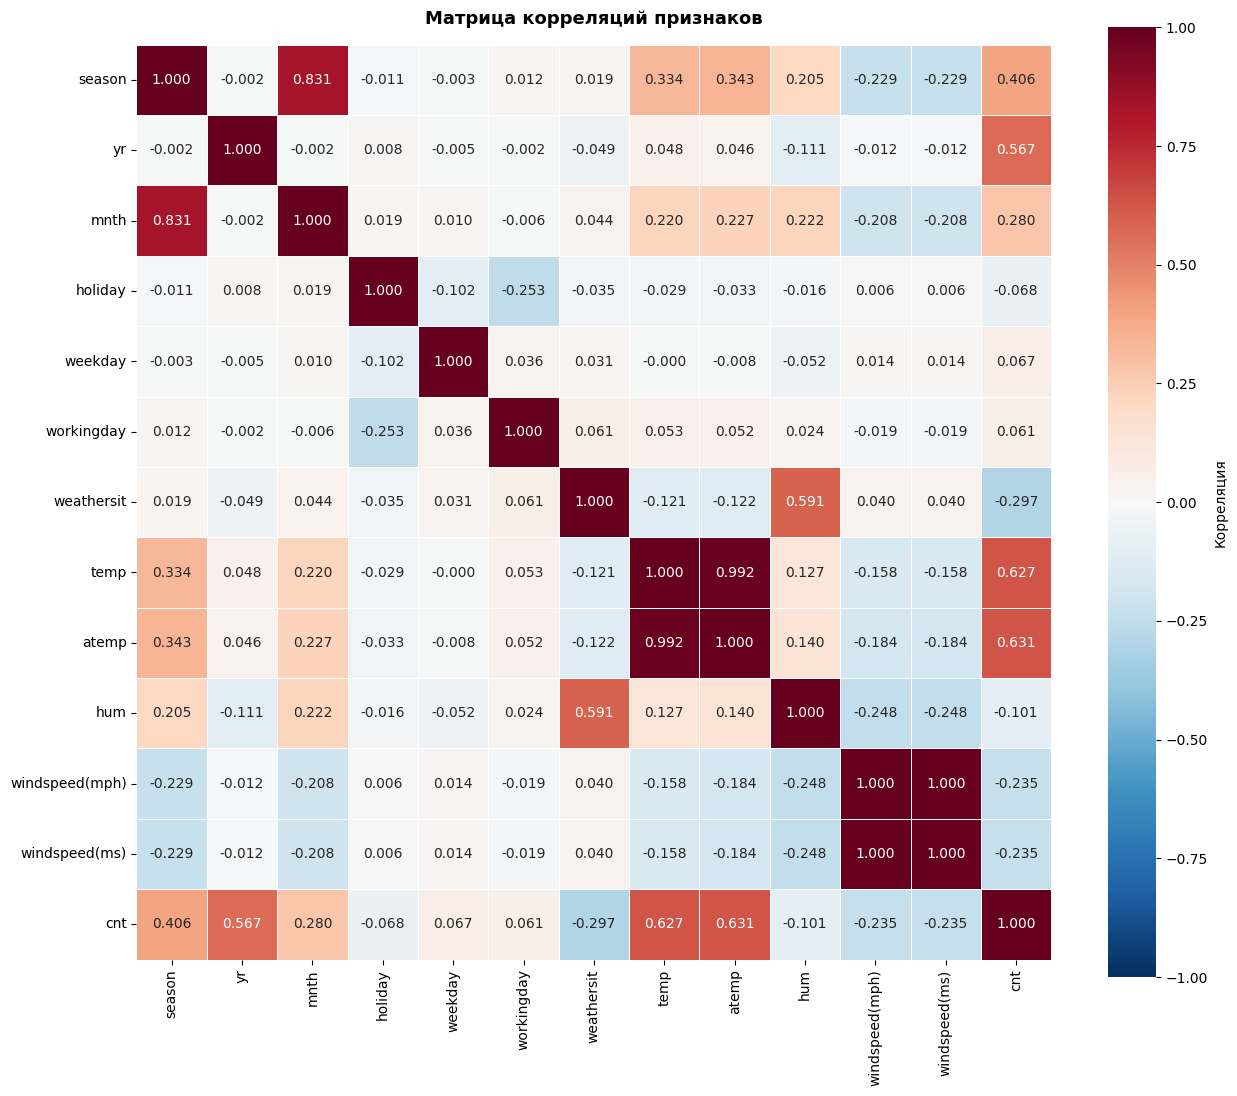

In [183]:
fig, ax = plt.subplots(figsize=(13, 11))
corr_matrix = df[numeric_cols + ['cnt']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, ax=ax, cbar_kws={'label': 'Корреляция'},
            linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Матрица корреляций признаков', fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.show()


In [184]:
target_corr = corr_matrix['cnt'].drop('cnt').sort_values(ascending=False)

for feature, value in target_corr.items():
    print(f"{feature:20s}: {value:.4f} ")


atemp               : 0.6311 
temp                : 0.6275 
yr                  : 0.5667 
season              : 0.4061 
mnth                : 0.2800 
weekday             : 0.0674 
workingday          : 0.0612 
holiday             : -0.0683 
hum                 : -0.1007 
windspeed(mph)      : -0.2345 
windspeed(ms)       : -0.2345 
weathersit          : -0.2974 


In [185]:
corr_ta = df['temp'].corr(df['atemp'])
print(f"   Корреляция между temp и atemp: {corr_ta:.4f}")

if corr_ta > 0.9:
    df_clean = df.drop(columns='atemp')
    print("Удален atemp")
    

corr_ws = df['windspeed(mph)'].corr(df['windspeed(ms)'])
print(f"   Корреляция между windspeed(mph) и windspeed(ms): {corr_ws:.4f}")

if corr_ws > 0.9:
    df_clean = df.drop(columns='windspeed(mph)')
    print("Удален windspeed(mph)")

   Корреляция между temp и atemp: 0.9917
Удален atemp
   Корреляция между windspeed(mph) и windspeed(ms): 1.0000
Удален windspeed(mph)


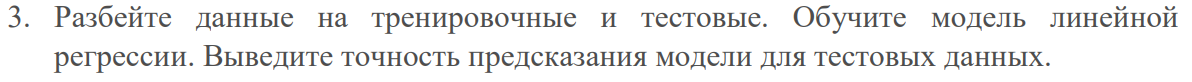

cnt = 1175.67
499.1731 * season
1970.7851 * yr
-39.1039 * mnth
-646.4418 * holiday
57.2725 * weekday
77.6986 * workingday
-630.3371 * weathersit
-74.2099 * temp
192.1596 * atemp
-11.1564 * hum
-59.1604 * windspeed(ms)
   yr                  : +1970.7851
   holiday             : -646.4418
   weathersit          : -630.3371
   season              : +499.1731
   atemp               : +192.1596
   workingday          : +77.6986
   temp                : -74.2099
   windspeed(ms)       : -59.1604
   weekday             : +57.2725
   mnth                : -39.1039
   hum                 : -11.1564
R²(train): 0.7984 (79.84%)
R²(test) : 0.7880 (78.80%)
RMSE: 901.87 
MAE: 657.85 


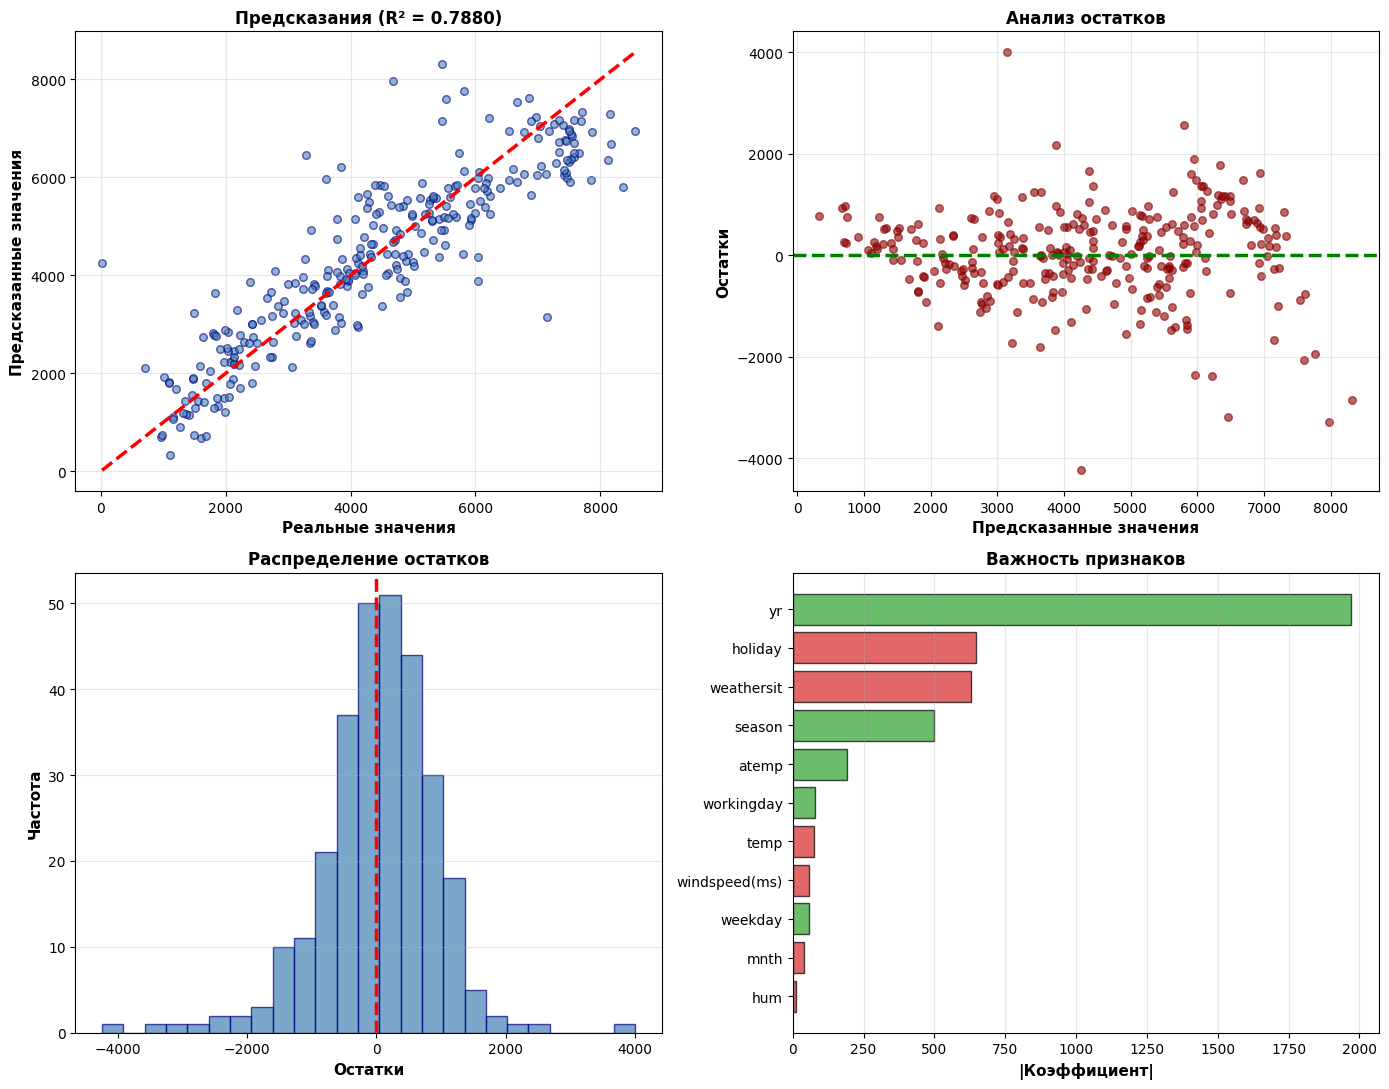

In [186]:
X = df_clean.drop(columns=['cnt'])
y = df_clean['cnt']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# Предсказания
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred_test)


print(f"cnt = {model.intercept_:.2f}")
for feat, coef in zip(X.columns, model.coef_):
    print(f"{coef:.4f} * {feat}")

sorted_features = sorted(zip(X.columns, model.coef_), 
                        key=lambda x: abs(x[1]), reverse=True)
for feat, coef in sorted_features:
    print(f"   {feat:20s}: {coef:+8.4f}")

print(f"R²(train): {r2_train:.4f} ({100*r2_train:.2f}%)")
print(f"R²(test) : {r2_test:.4f} ({100*r2_test:.2f}%)")
print(f"RMSE: {rmse_test:.2f} ")
print(f"MAE: {mae_test:.2f} ")

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# График 1: Предсказания vs Реальные значения
ax = axes[0, 0]
ax.scatter(y_test, y_pred_test, alpha=0.6, s=30, color='steelblue', edgecolor='navy')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2.5)
ax.set_xlabel('Реальные значения', fontweight='bold', fontsize=11)
ax.set_ylabel('Предсказанные значения', fontweight='bold', fontsize=11)
ax.set_title(f'Предсказания (R² = {r2_test:.4f})', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
residuals = y_test - y_pred_test
ax.scatter(y_pred_test, residuals, alpha=0.6, s=30, color='darkred', edgecolor='darkred')
ax.axhline(y=0, color='green', linestyle='--', linewidth=2.5)
ax.set_xlabel('Предсказанные значения', fontweight='bold', fontsize=11)
ax.set_ylabel('Остатки', fontweight='bold', fontsize=11)
ax.set_title('Анализ остатков', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.hist(residuals, bins=25, color='steelblue', alpha=0.7, edgecolor='navy')
ax.axvline(0, color='red', linestyle='--', linewidth=2.5)
ax.set_xlabel('Остатки', fontweight='bold', fontsize=11)
ax.set_ylabel('Частота', fontweight='bold', fontsize=11)
ax.set_title('Распределение остатков', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 1]
importance = pd.DataFrame({'Feature': X.columns, 'AbsCoef': abs(model.coef_)}).sort_values('AbsCoef')
colors = ['#d62728' if model.coef_[list(X.columns).index(f)] < 0 else '#2ca02c' 
          for f in importance['Feature']]
ax.barh(importance['Feature'], importance['AbsCoef'], color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('|Коэффициент|', fontweight='bold', fontsize=11)
ax.set_title('Важность признаков', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


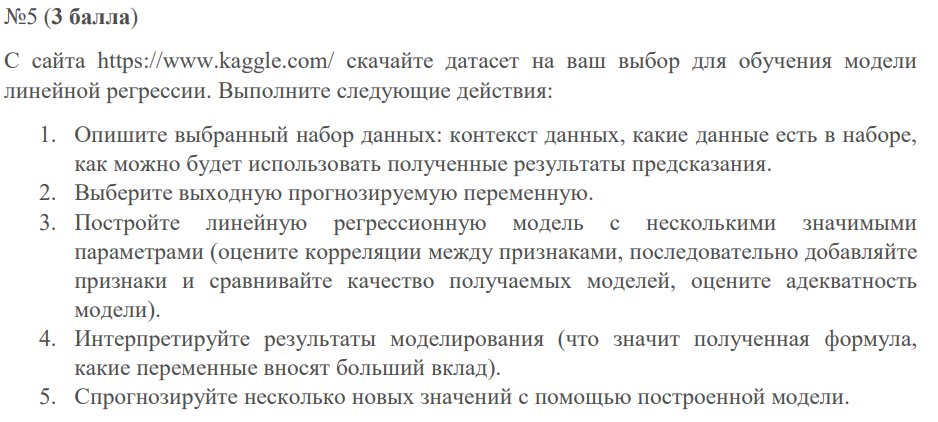

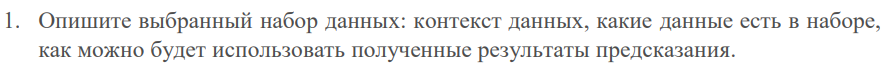

In [187]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
df = pd.read_csv('Exam_Score_Prediction.csv')

df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


student_id: уникальный идентификатор студента  
age: возраст студента (17-24 лет)  
gender: пол (male, female, other)  
course: специальность (diploma, bca, b.sc, b.tech, bba, ba, b.com)  
study_hours: часов в неделю на учёбу (0-8 часов)  
class_attendance: посещаемость классов (0-100%)  
internet_access: доступ в интернет (yes/no)  
sleep_hours: часов сна в сутки (4-10 часов)  
sleep_quality: качество сна (poor, average, good)  
study_method: метод подготовки (coaching, online videos, self-study, group study, mixed)  
facility_rating: рейтинг учебных условий (low, medium, high)  
exam_difficulty: сложность экзамена (easy, moderate, hard)  
exam_score: итоговый балл экзамена (0-100)  

Эти данные можно использовать для:
   1. Рекомендации студентам оптимальных часов учёбы для повышения балла
   2. Определения влияния посещаемости на результаты
   3. Оценки важности качества сна для успеха
   4. Выбора оптимального метода подготовки
   5. Прогноза ожидаемого балла студента по его учебным привычкам

exam_score: итоговый балл экзамена (0-100)  

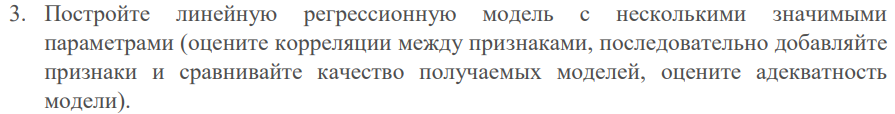

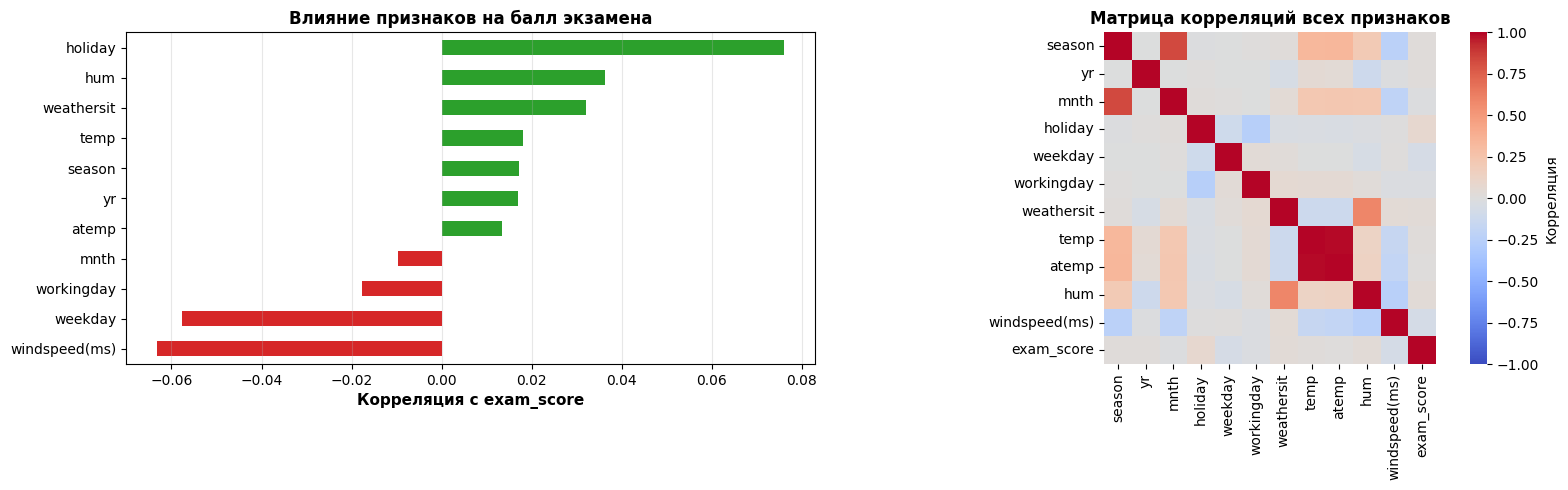

In [188]:
df_model = df.copy()

# Целевая переменная
y = df_model['exam_score']

# Выбираем признаки (исключаем student_id и целевую переменную)
X_all = df_model.drop(['student_id', 'exam_score'], axis=1)

categorical_cols = X_all.select_dtypes(include=['object']).columns.tolist()

le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_all[col] = le.fit_transform(X_all[col])
    le_dict[col] = le

X_all = X_all.astype(float)
y = y.astype(float)

data_corr = X.copy()
data_corr['exam_score'] = y

corr_matrix = data_corr.corr()
target_corr = corr_matrix['exam_score'].drop('exam_score').sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# График 1: Корреляция с целевой переменной
ax = axes[0]
target_corr.sort_values().plot(kind='barh', ax=ax, color=['#d62728' if x < 0 else '#2ca02c' for x in target_corr.sort_values().values])
ax.set_xlabel('Корреляция с exam_score', fontweight='bold', fontsize=11)
ax.set_title('Влияние признаков на балл экзамена', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

ax = axes[1]
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, ax=ax, cbar_kws={'label': 'Корреляция'},
            vmin=-1, vmax=1)
ax.set_title('Матрица корреляций всех признаков', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

In [189]:
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42)

all_data = X_all.copy()
all_data['exam_score'] = y
correlations = all_data.corr()['exam_score'].drop('exam_score').abs().sort_values(ascending=False)

results = []
feature_sets = []
models = []

feature_list = [correlations.index[0]]
X_train = X_train_all[feature_list]
X_test = X_test_all[feature_list]

model = LinearRegression()
model.fit(X_train, y_train)
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"   Признаки: {feature_list}")
print(f"   R² (train): {r2_train:.4f}  |  R² (test): {r2_test:.4f}  |  MAE: {mae_test:.2f}  |  RMSE: {rmse_test:.2f}")

results.append({
    'Модель': 1,
    'Количество признаков': len(feature_list),
    'R² train': r2_train,
    'R² test': r2_test,
    'MAE': mae_test,
    'RMSE': rmse_test,
    'Признаки': ', '.join(feature_list)
})
feature_sets.append(feature_list.copy())
models.append(model)

# Модели 2-5: Добавляем признаки по одному
for num_features in range(2, min(6, len(correlations) + 1)):
    print(f"\n" + "-" * 100)
    print(f"MODEL {num_features}: добавили {num_features} признаков")
    print(f"-" * 100)
    
    feature_list = list(correlations.index[:num_features])
    X_train = X_train_all[feature_list]
    X_test = X_test_all[feature_list]
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    print(f"   Признаки: {feature_list}")
    print(f"   R² (train): {r2_train:.4f}  |  R² (test): {r2_test:.4f}  |  MAE: {mae_test:.2f}  |  RMSE: {rmse_test:.2f}")
    
    results.append({
        'Модель': num_features,
        'Количество признаков': len(feature_list),
        'R² train': r2_train,
        'R² test': r2_test,
        'MAE': mae_test,
        'RMSE': rmse_test,
        'Признаки': ', '.join(feature_list)
    })
    feature_sets.append(feature_list.copy())
    models.append(model)

# Модель с ВСЕ признаками
print(f"\n" + "-" * 100)
print(f"MODEL {len(correlations)}: ВСЕ {len(correlations)} признаков")
print(f"-" * 100)

feature_list = list(X_all.columns)
X_train = X_train_all[feature_list]
X_test = X_test_all[feature_list]

model_full = LinearRegression()
model_full.fit(X_train, y_train)
y_pred_train = model_full.predict(X_train)
y_pred_test = model_full.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"   Признаки: все {len(feature_list)}")
print(f"   R² (train): {r2_train:.4f}  |  R² (test): {r2_test:.4f}  |  MAE: {mae_test:.2f}  |  RMSE: {rmse_test:.2f}")

results.append({
    'Модель': 'Full',
    'Количество признаков': len(feature_list),
    'R² train': r2_train,
    'R² test': r2_test,
    'MAE': mae_test,
    'RMSE': rmse_test,
    'Признаки': f'все {len(feature_list)}'
})

   Признаки: ['study_hours']
   R² (train): 0.5129  |  R² (test): 0.5245  |  MAE: 10.64  |  RMSE: 13.04

----------------------------------------------------------------------------------------------------
MODEL 2: добавили 2 признаков
----------------------------------------------------------------------------------------------------
   Признаки: ['study_hours', 'class_attendance']
   R² (train): 0.6122  |  R² (test): 0.6077  |  MAE: 9.58  |  RMSE: 11.85

----------------------------------------------------------------------------------------------------
MODEL 3: добавили 3 признаков
----------------------------------------------------------------------------------------------------
   Признаки: ['study_hours', 'class_attendance', 'study_method']
   R² (train): 0.6359  |  R² (test): 0.6292  |  MAE: 9.30  |  RMSE: 11.52

----------------------------------------------------------------------------------------------------
MODEL 4: добавили 4 признаков
------------------------------------

In [192]:
results_df = pd.DataFrame(results)
print("\nСравнительная таблица:")
print(results_df.to_string(index=False))

# Найти лучшую модель по R² test
best_idx = results_df['R² test'].idxmax()
best_model_num = results_df.iloc[best_idx]['Модель']
best_r2 = results_df.iloc[best_idx]['R² test']

print(f"\nЛучшая модель: {best_model_num}")
print(f"   R² (test): {best_r2:.4f}")
print(f"   MAE: {results_df.iloc[best_idx]['MAE']:.2f}")
print(f"   RMSE: {results_df.iloc[best_idx]['RMSE']:.2f}")


Сравнительная таблица:
Модель  Количество признаков  R² train  R² test       MAE      RMSE                                                                Признаки
     1                     1  0.512894 0.524475 10.640548 13.042004                                                             study_hours
     2                     2  0.612205 0.607666  9.583767 11.846383                                           study_hours, class_attendance
     3                     3  0.635857 0.629178  9.300360 11.517035                             study_hours, class_attendance, study_method
     4                     4  0.653150 0.650436  9.034942 11.182039                study_hours, class_attendance, study_method, sleep_hours
     5                     5  0.663347 0.661788  8.868736 10.998968 study_hours, class_attendance, study_method, sleep_hours, sleep_quality
  Full                    11  0.669565 0.667447  8.800584 10.906564                                                                  все

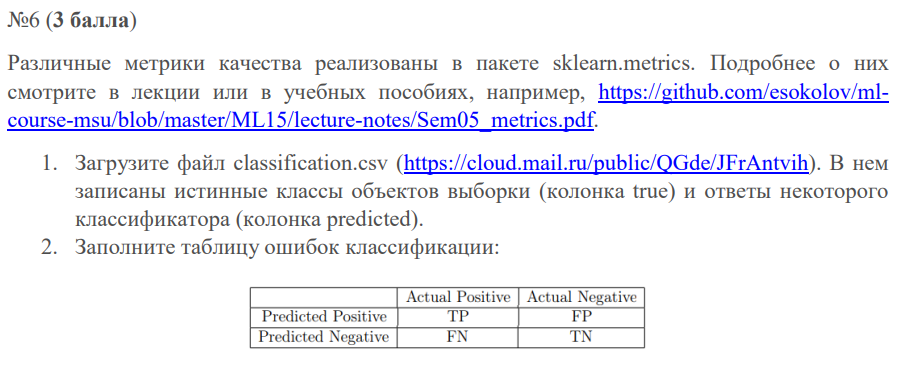
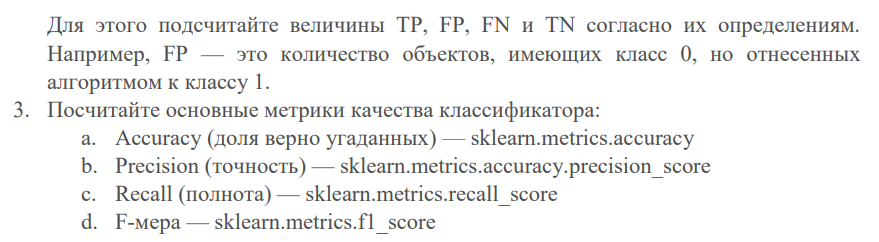

In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

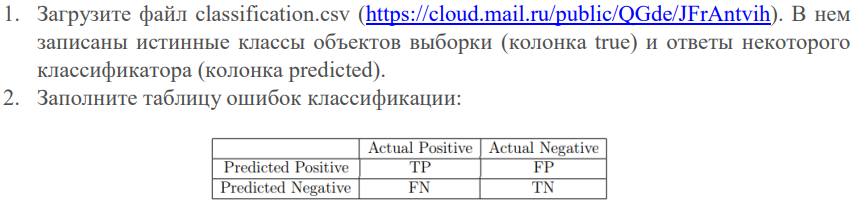

In [200]:
df = pd.read_csv('classification.csv')
print(df.head(10))

y_true = df['true'].astype(int)
y_pred = df['pred'].astype(int)

TP = ((y_pred == 1) & (y_true == 1)).sum()
FP = ((y_pred == 1) & (y_true == 0)).sum()
FN = ((y_pred == 0) & (y_true == 1)).sum()
TN = ((y_pred == 0) & (y_true == 0)).sum()
total = TP + FP + FN + TN

print(f"\n📊 КОМПОНЕНТЫ МАТРИЦЫ ОШИБОК:")
print(f"\n   TP (True Positive)   = {TP}")
print(f"      Истинно положительные - объекты с классом 1, предсказанные как 1")

print(f"\n   FP (False Positive)  = {FP}")
print(f"      Ложно положительные - объекты с классом 0, предсказанные как 1")

print(f"\n   FN (False Negative)  = {FN}")
print(f"      Ложно отрицательные - объекты с классом 1, предсказанные как 0")

print(f"\n   TN (True Negative)   = {TN}")
print(f"      Истинно отрицательные - объекты с классом 0, предсказанные как 0")

print(f"\n✅ Проверка: {TP} + {FP} + {FN} + {TN} = {total}")

# Таблица матрицы ошибок
print(f"\n" + "─" * 120)
print(f"{'':35s} | Actual Positive | Actual Negative")
print(f"{'-'*35}-+-----------------+-----------------")
print(f"{'Predicted Positive':35s} | {TP:15d} | {FP:15d}")
print(f"{'Predicted Negative':35s} | {FN:15d} | {TN:15d}")
print(f"─" * 120)

   true  pred  Unnamed: 2
0     1     0         NaN
1     1     1         NaN
2     1     1         NaN
3     0     0         NaN
4     1     1         NaN
5     1     1         NaN
6     1     1         NaN
7     0     1         NaN
8     0     0         NaN
9     0     1         NaN

📊 КОМПОНЕНТЫ МАТРИЦЫ ОШИБОК:

   TP (True Positive)   = 43
      Истинно положительные - объекты с классом 1, предсказанные как 1

   FP (False Positive)  = 34
      Ложно положительные - объекты с классом 0, предсказанные как 1

   FN (False Negative)  = 59
      Ложно отрицательные - объекты с классом 1, предсказанные как 0

   TN (True Negative)   = 64
      Истинно отрицательные - объекты с классом 0, предсказанные как 0

✅ Проверка: 43 + 34 + 59 + 64 = 200

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                    | Actual Positive | Actual Negative
------------------------------------+----------------

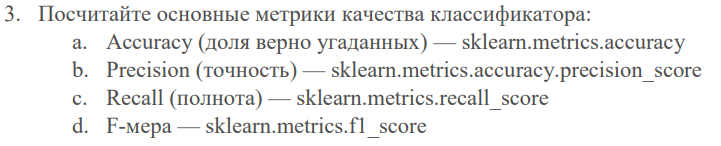

In [206]:
accuracy = (TP + TN) / total
print(f"\nACCURACY (Доля верно угаданных):")
print(f"Вычисление: ({TP} + {TN}) / {total} = {accuracy:.4f}")

# Precision
if (TP + FP) > 0:
    precision = TP / (TP + FP)
else:
    precision = 0
    
print(f"\nPRECISION (Точность положительного класса):")
print(f"Вычисление: {TP} / ({TP} + {FP}) = {TP} / {TP + FP} = {precision:.4f}")

# Recall
if (TP + FN) > 0:
    recall = TP / (TP + FN)
else:
    recall = 0

print(f"\nRECALL (Полнота, чувствительность):")
print(f"Вычисление: {TP} / ({TP} + {FN}) = {TP} / {TP + FN} = {recall:.4f}")

# F1-score
if (precision + recall) > 0:
    f1 = 2 * (precision * recall) / (precision + recall)
else:
    f1 = 0

print(f"\nF1-SCORE (Гармоническое среднее):")
print(f"Вычисление: 2 * ({precision:.4f} * {recall:.4f}) / ({precision:.4f} + {recall:.4f}) = {f1:.4f}")

# Specificity
if (TN + FP) > 0:
    specificity = TN / (TN + FP)
else:
    specificity = 0

print(f"\nSPECIFICITY (Специфичность):")
print(f"Вычисление: {TN} / ({TN} + {FP}) = {TN} / {TN + FP} =  {specificity:.4f}")

# FPR и FNR
if (FP + TN) > 0:
    fpr = FP / (FP + TN)
else:
    fpr = 0

if (FN + TP) > 0:
    fnr = FN / (FN + TP)
else:
    fnr = 0

print(f"\nFPR (False Positive Rate):")
print(f"Результат: {fpr:.4f}")

print(f"\nFNR (False Negative Rate):")
print(f"Результат: {fnr:.4f}")


ACCURACY (Доля верно угаданных):
Вычисление: (43 + 64) / 200 = 0.5350

PRECISION (Точность положительного класса):
Вычисление: 43 / (43 + 34) = 43 / 77 = 0.5584

RECALL (Полнота, чувствительность):
Вычисление: 43 / (43 + 59) = 43 / 102 = 0.4216

F1-SCORE (Гармоническое среднее):
Вычисление: 2 * (0.5584 * 0.4216) / (0.5584 + 0.4216) = 0.4804

SPECIFICITY (Специфичность):
Вычисление: 64 / (64 + 34) = 64 / 98 =  0.6531

FPR (False Positive Rate):
Результат: 0.3469

FNR (False Negative Rate):
Результат: 0.5784


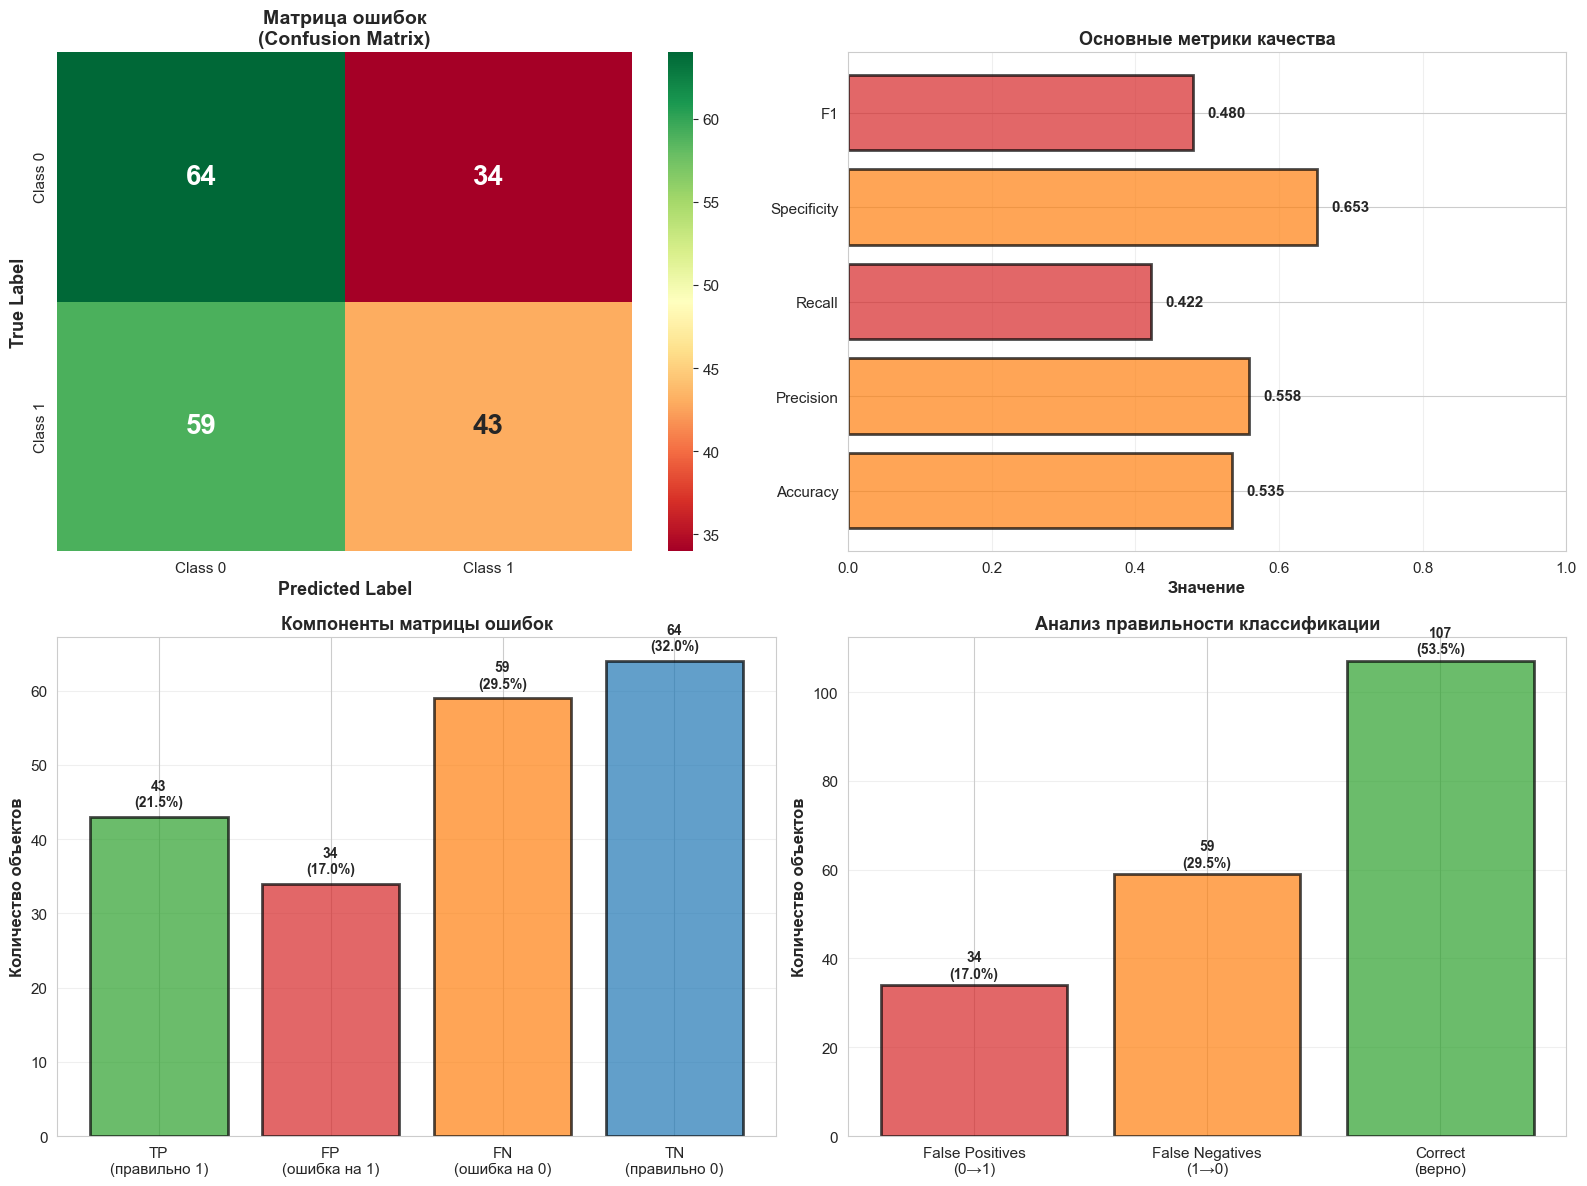

In [207]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# График 1: Матрица ошибок (тепловая карта)
ax = axes[0, 0]
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', cbar=True, ax=ax,
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'],
            annot_kws={'size': 20, 'weight': 'bold'})
ax.set_xlabel('Predicted Label', fontweight='bold', fontsize=13)
ax.set_ylabel('True Label', fontweight='bold', fontsize=13)
ax.set_title('Матрица ошибок\n(Confusion Matrix)', fontweight='bold', fontsize=14)

# График 2: Метрики качества
ax = axes[0, 1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1']
metrics_values = [accuracy, precision, recall, specificity, f1]
colors = ['#2ca02c' if v >= 0.7 else '#ff7f0e' if v >= 0.5 else '#d62728' for v in metrics_values]
bars = ax.barh(metrics_names, metrics_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_xlim([0, 1])
ax.set_xlabel('Значение', fontweight='bold', fontsize=12)
ax.set_title('Основные метрики качества', fontweight='bold', fontsize=13)
ax.grid(True, alpha=0.3, axis='x')

for bar, val in zip(bars, metrics_values):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, 
            f'{val:.3f}', va='center', fontsize=11, fontweight='bold')

# График 3: Распределение компонентов
ax = axes[1, 0]
categories = ['TP\n(правильно 1)', 'FP\n(ошибка на 1)', 'FN\n(ошибка на 0)', 'TN\n(правильно 0)']
values = [TP, FP, FN, TN]
colors_dist = ['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4']
bars = ax.bar(categories, values, color=colors_dist, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Количество объектов', fontweight='bold', fontsize=12)
ax.set_title('Компоненты матрицы ошибок', fontweight='bold', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{int(val)}\n({100*val/total:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# График 4: Анализ ошибок
ax = axes[1, 1]
error_categories = ['False Positives\n(0→1)', 'False Negatives\n(1→0)', 'Correct\n(верно)']
error_values = [FP, FN, TP + TN]
error_colors = ['#d62728', '#ff7f0e', '#2ca02c']
bars = ax.bar(error_categories, error_values, color=error_colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Количество объектов', fontweight='bold', fontsize=12)
ax.set_title('Анализ правильности классификации', fontweight='bold', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, error_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{int(val)}\n({100*val/total:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

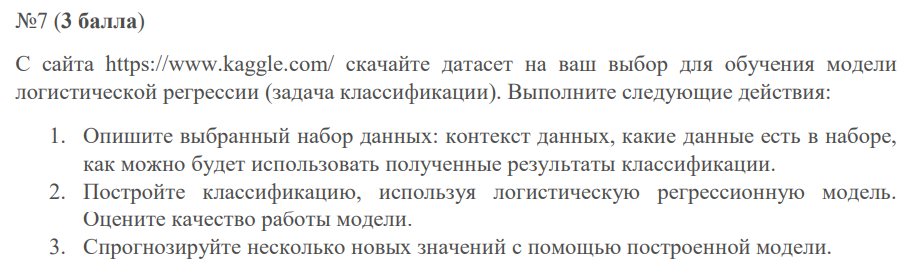

radius - радиус опухоли (размер)  
texture - текстура (однородность)  
perimeter - периметр (длина границы)  
area - площадь (размер в пикселях)  
smoothness - гладкость поверхности  
compactness - компактность формы  
concavity - вогнутость контура  
concave points - количество вогнутых точек  
symmetry - симметричность  
fractal_dimension - фрактальная размерность  

diagnosis - целевой

ПРИМЕНЕНИЕ РЕЗУЛЬТАТОВ:  
Ранняя диагностика рака молочной железы  
Помощь врачам при принятии решения о необходимости биопсии  
Быстрая классификация опухолей для приоритизации пациентов  
Повышение точности диагностики через автоматическое анализирование  
Снижение затрат на медицинское обследование  

In [211]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


df = pd.read_csv('breast-cancer.csv')
print(df.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

In [221]:
target_col = 'diagnosis'

if df[target_col].dtype == 'object':
    le = LabelEncoder()
    df[target_col] = le.fit_transform(df[target_col])
    
X = df.drop(target_col, axis=1)
y = df[target_col].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y)

model = LogisticRegression(max_iter=10000, random_state=42, solver='lbfgs')
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
y_pred_proba_train = model.predict_proba(X_train)[:, 1]
y_pred_proba_test = model.predict_proba(X_test)[:, 1]

# Метрики ОБУЧАЮЩЕЙ выборки
print(f"\nTrain:")
acc_train = accuracy_score(y_train, y_pred_train)
prec_train = precision_score(y_train, y_pred_train)
rec_train = recall_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)

print(f"Accuracy:  {acc_train:.4f}")
print(f"Precision: {prec_train:.4f}")
print(f"Recall:    {rec_train:.4f}")
print(f"F1-Score:  {f1_train:.4f}")

# Метрики ТЕСТОВОЙ выборки
print(f"\nTest:")
acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test)
rec_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
roc_auc_test = roc_auc_score(y_test, y_pred_proba_test)

print(f"Accuracy:  {acc_test:.4f} ")
print(f"Precision: {prec_test:.4f} ")
print(f"Recall:    {rec_test:.4f} ")
print(f"F1-Score:  {f1_test:.4f} ")
print(f"ROC-AUC:   {roc_auc_test:.4f}")



Train:
Accuracy:  0.9912
Precision: 1.0000
Recall:    0.9765
F1-Score:  0.9881

Test:
Accuracy:  0.9649 
Precision: 1.0000 
Recall:    0.9048 
F1-Score:  0.9500 
ROC-AUC:   0.9954


In [222]:
print(f"\nCONFUSION MATRIX:")
cm = confusion_matrix(y_test, y_pred_test)
TP = cm[1, 1]
FP = cm[0, 1]
FN = cm[1, 0]
TN = cm[0, 0]

print(f"                  | Actual Benign | Actual Cancer")
print(f"Predicted Benign  | {TN:13d} | {FN:13d}")
print(f"Predicted Cancer  | {FP:13d} | {TP:13d}")

print(f"\nDetailed Report:")
print(classification_report(y_test, y_pred_test, 
                          target_names=['Benign', 'Malignant']))


CONFUSION MATRIX:
                  | Actual Benign | Actual Cancer
Predicted Benign  |            72 |             4
Predicted Cancer  |             0 |            38

Detailed Report:
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [ ]:
print(f"\nПРИМЕР 1: ЗДОРОВЫЙ ПАЦИЕНТ (Benign)")
healthy = X_scaled[y.values == 0].iloc[0:1]
pred = model.predict(healthy)[0]
proba = model.predict_proba(healthy)[0]
print(f"   Вероятность Benign: {100*proba[0]:.2f}%")
print(f"   Вероятность Cancer: {100*proba[1]:.2f}%")
print(f"   Предсказание: {'BENIGN' if pred == 0 else 'CANCER'}")

print(f"\nПРИМЕР 2: ПАЦИЕНТ С РАКОМ (Malignant)")
sick = X_scaled[y.values == 1].iloc[0:1]
pred = model.predict(sick)[0]
proba = model.predict_proba(sick)[0]
print(f"   Вероятность Benign: {100*proba[0]:.2f}%")
print(f"   Вероятность Cancer: {100*proba[1]:.2f}%")
print(f"   Предсказание: {'BENIGN' if pred == 0 else 'CANCER'}")

print(f"\nПРИМЕР 3: СРЕДНИЙ ПАЦИЕНТ")
mean_patient = X_scaled.mean().values.reshape(1, -1)
pred = model.predict(mean_patient)[0]
proba = model.predict_proba(mean_patient)[0]
print(f"   Вероятность Benign: {100*proba[0]:.2f}%")
print(f"   Вероятность Cancer: {100*proba[1]:.2f}%")
print(f"   Предсказание: {'BENIGN' if pred == 0 else 'CANCER'}")


🏥 ПРИМЕР 1: ЗДОРОВЫЙ ПАЦИЕНТ (Benign)
   Вероятность Benign: 91.40%
   Вероятность Cancer: 8.60%
   Предсказание: BENIGN

🏥 ПРИМЕР 2: ПАЦИЕНТ С РАКОМ (Malignant)
   Вероятность Benign: 0.00%
   Вероятность Cancer: 100.00%
   Предсказание: CANCER

🏥 ПРИМЕР 3: СРЕДНИЙ ПАЦИЕНТ
   Вероятность Benign: 51.99%
   Вероятность Cancer: 48.01%
   Предсказание: BENIGN


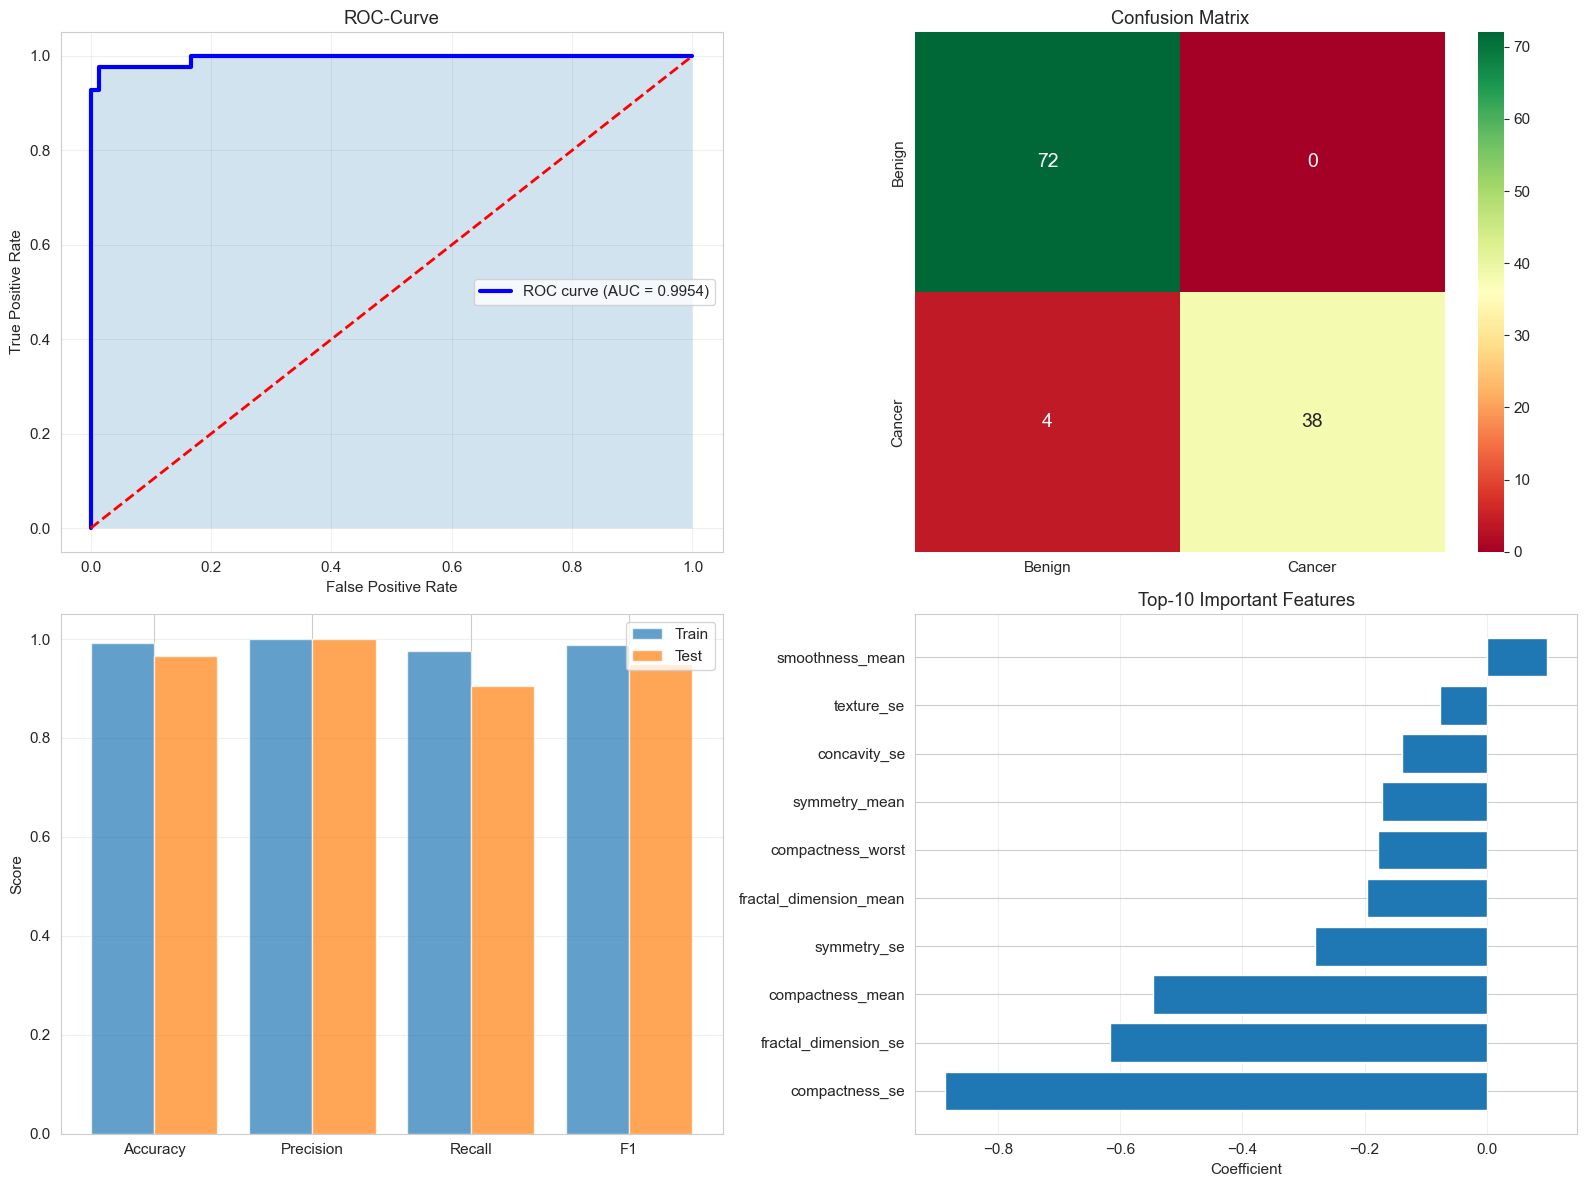

In [225]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# График 1: ROC-кривая
ax = axes[0, 0]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_test)
ax.plot(fpr, tpr, 'b-', linewidth=3, label=f'ROC curve (AUC = {roc_auc_test:.4f})')
ax.plot([0, 1], [0, 1], 'r--', linewidth=2)
ax.fill_between(fpr, tpr, alpha=0.2)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-Curve')
ax.legend()
ax.grid(alpha=0.3)

# График 2: Матрица ошибок
ax = axes[0, 1]
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', ax=ax,
            xticklabels=['Benign', 'Cancer'],
            yticklabels=['Benign', 'Cancer'],
            annot_kws={'size': 14})
ax.set_title('Confusion Matrix')

# График 3: Метрики
ax = axes[1, 0]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
train_vals = [acc_train, prec_train, rec_train, f1_train]
test_vals = [acc_test, prec_test, rec_test, f1_test]
x = np.arange(len(metrics))
ax.bar(x - 0.2, train_vals, 0.4, label='Train', alpha=0.7)
ax.bar(x + 0.2, test_vals, 0.4, label='Test', alpha=0.7)
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(alpha=0.3, axis='y')

# График 4: Коэффициенты
ax = axes[1, 1]
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient').head(10)
ax.barh(coef_df['Feature'], coef_df['Coefficient'])
ax.set_xlabel('Coefficient')
ax.set_title('Top-10 Important Features')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()